CUSTOMER PERSONALITY ANALYSIS - EDA REPORT

Dataset Shape:
(2240, 29)

First 5 Rows:
     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  AcceptedCmp3  \
0  04-09-2012       58       635  ...                  7             0   
1  08-03-2014       38        11  ...                  5             0   
2  21-08-2013       26       426  ...                  4             0   
3  10-02-2014       26        11  ...                  6             0   
4  19-01-2014       94       173  ...                  5             0   

 

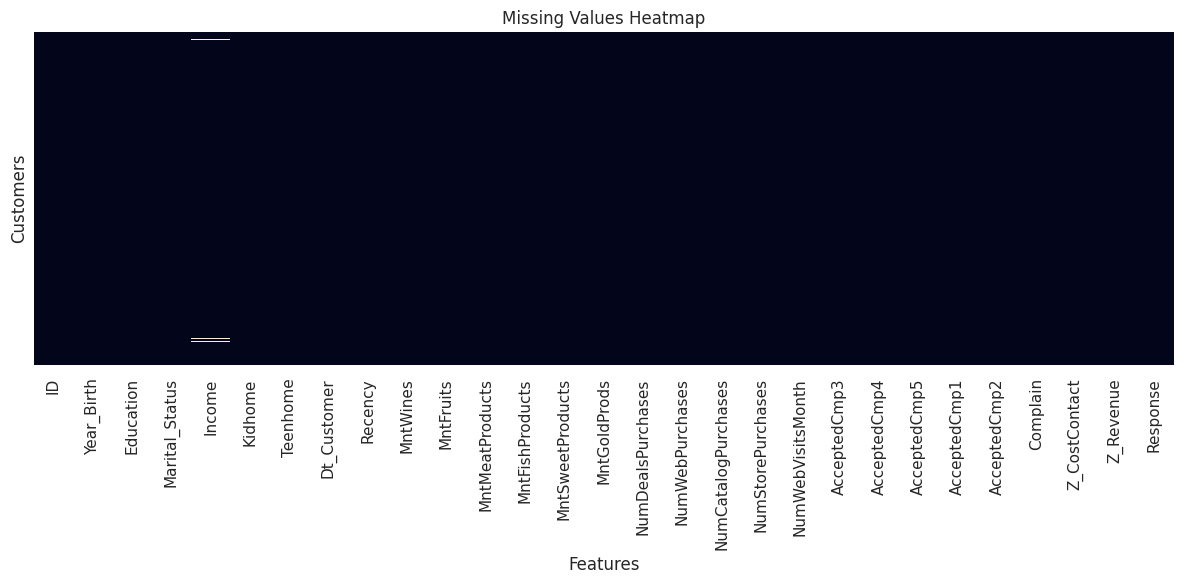


DUPLICATE ANALYSIS
Number of duplicate rows: 0
Shape after removing duplicates: (2240, 29)

Data cleaning completed.

Age feature created successfully.
Total_Spending feature created successfully.


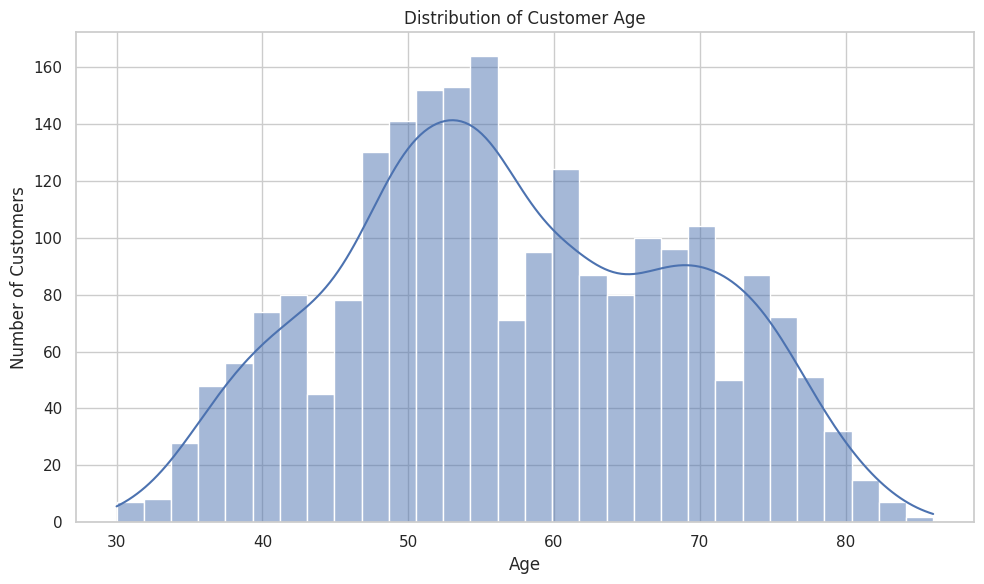

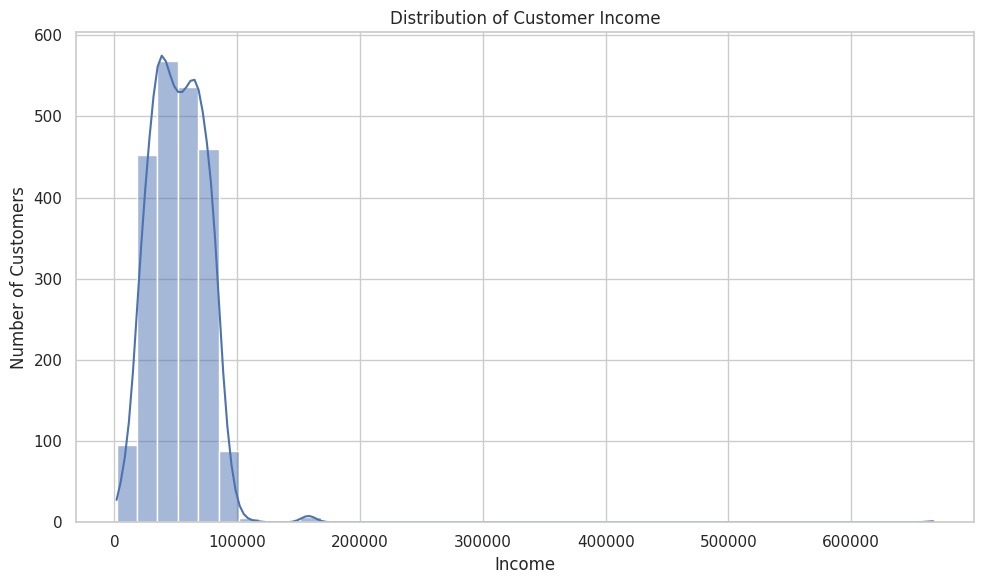

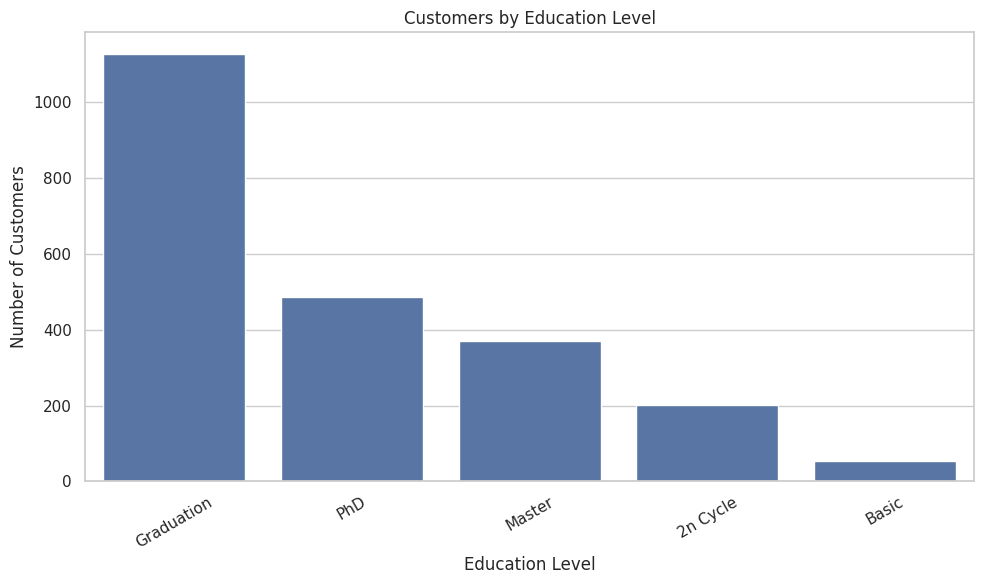

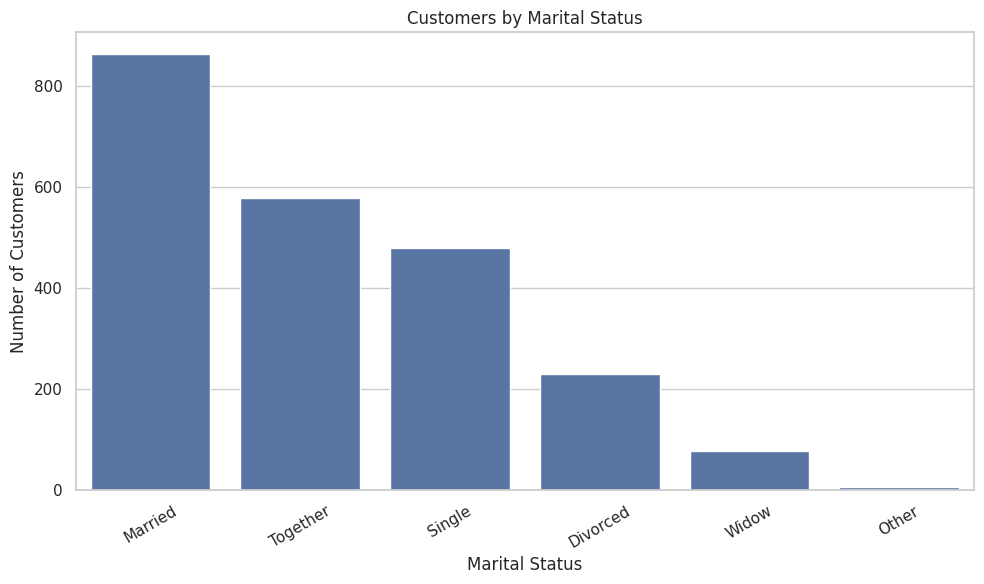

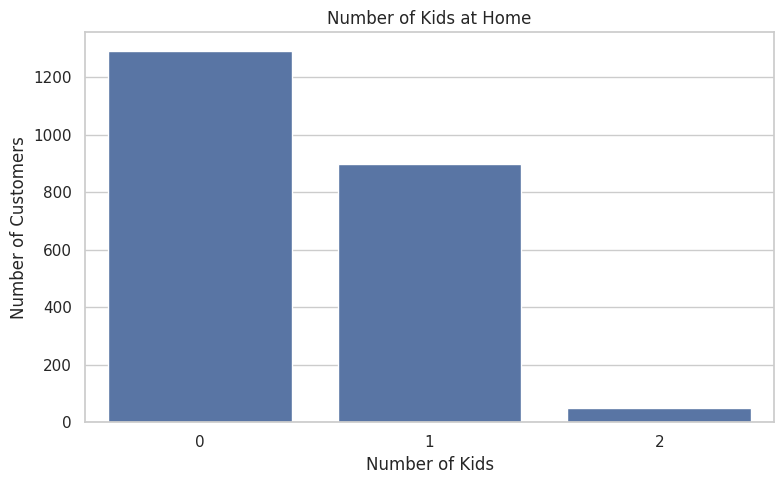

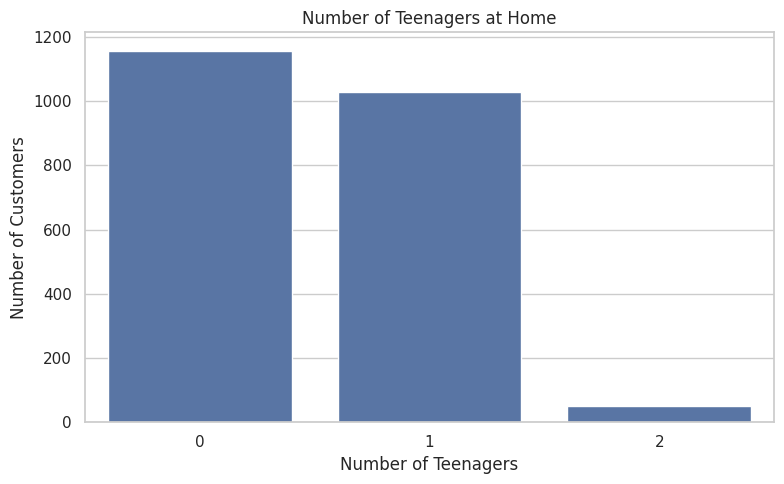

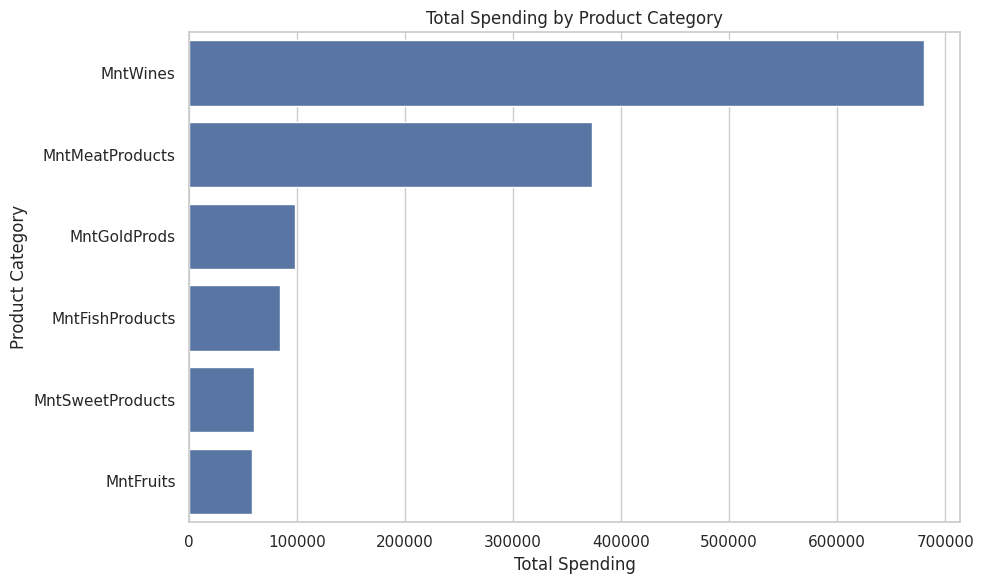

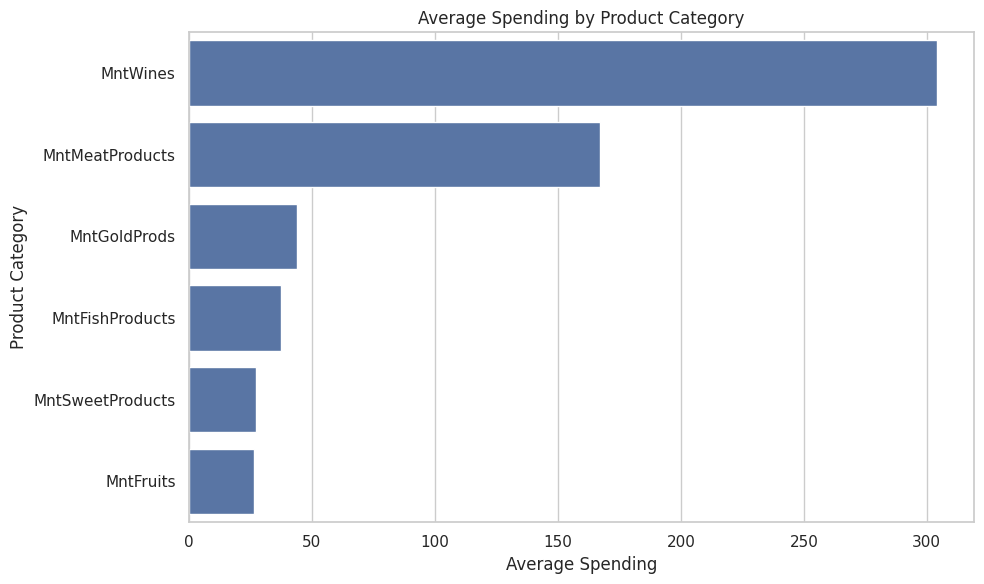

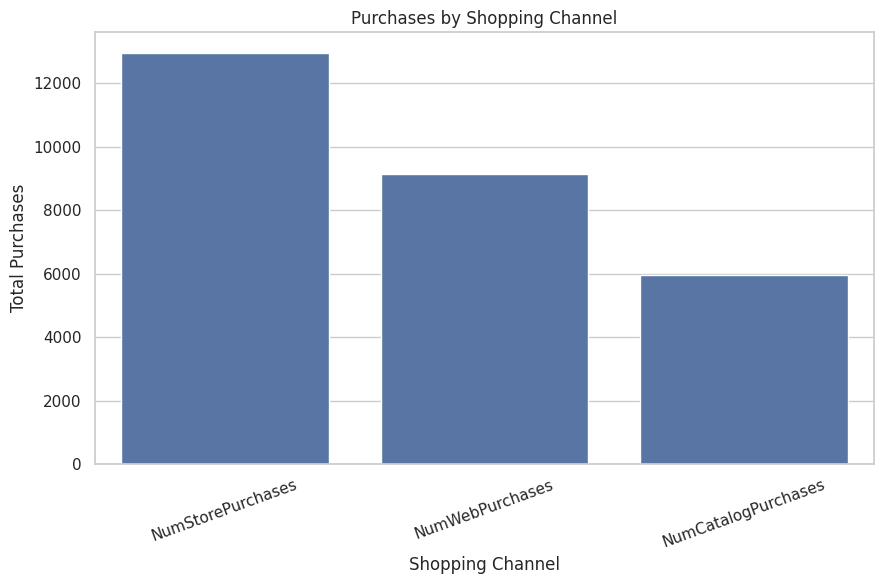

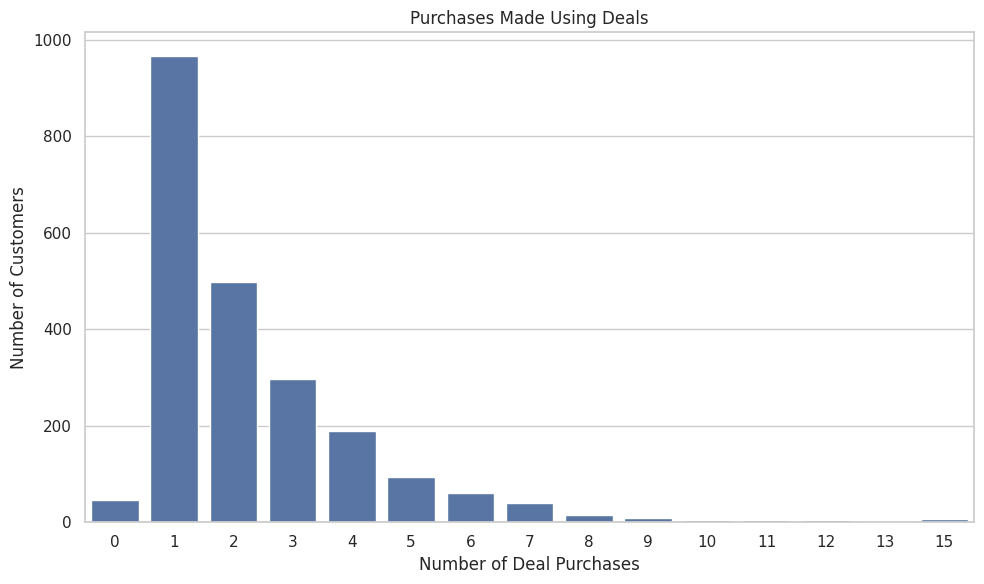

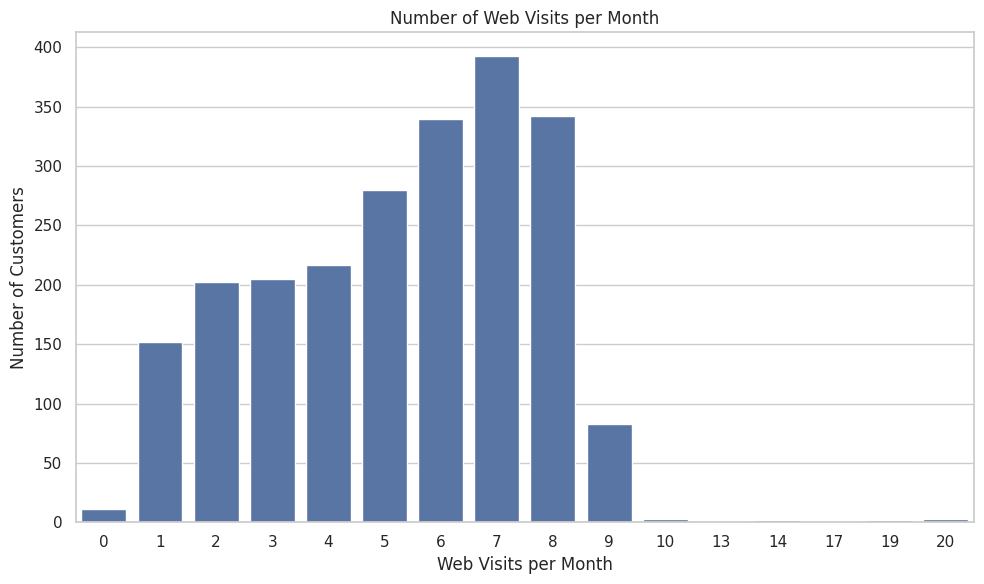

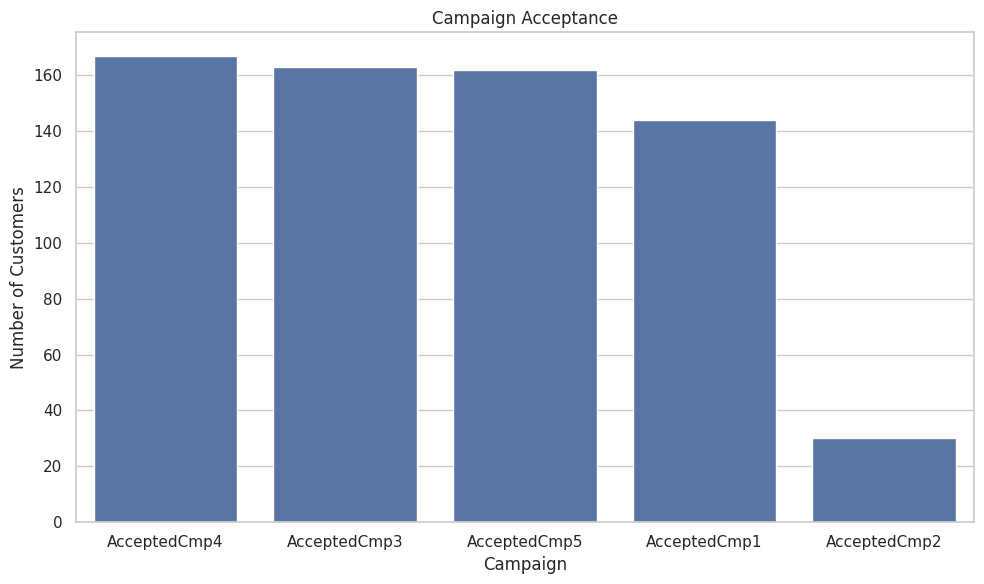

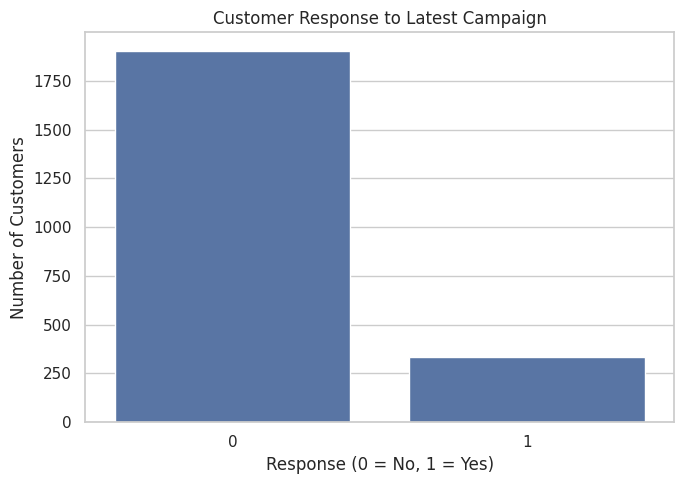


CAMPAIGN RESPONSE RATE
Latest Campaign Response Rate: 14.93%


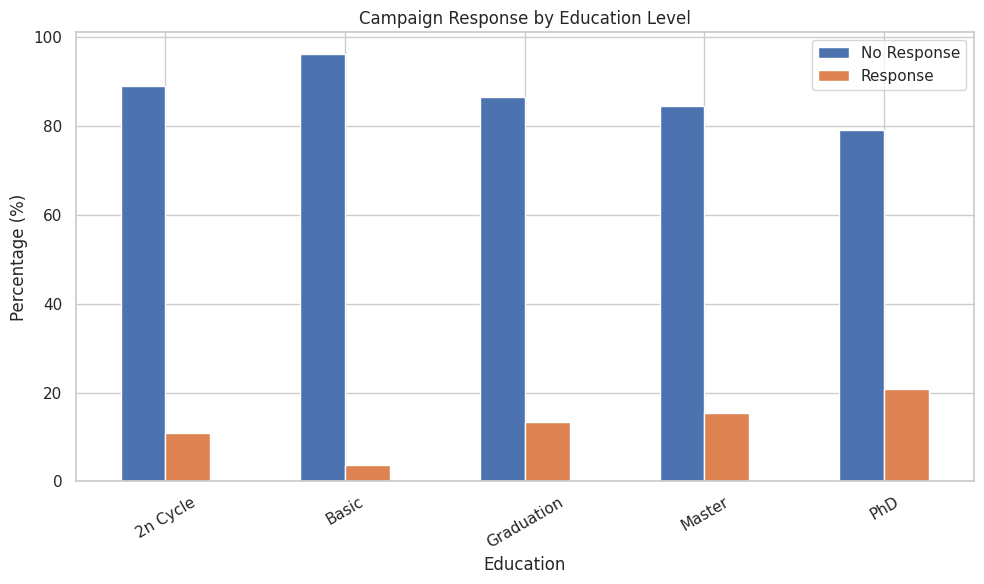

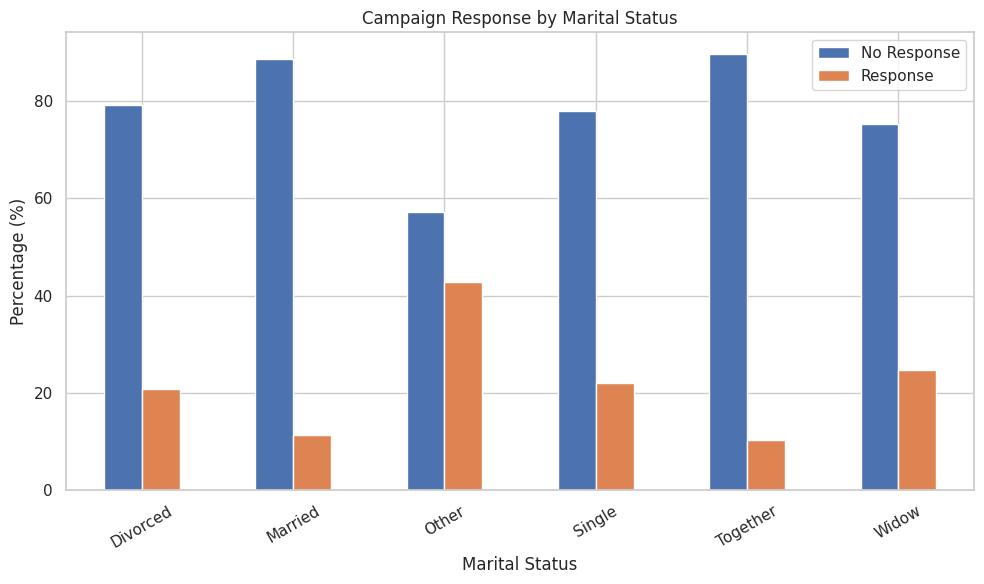

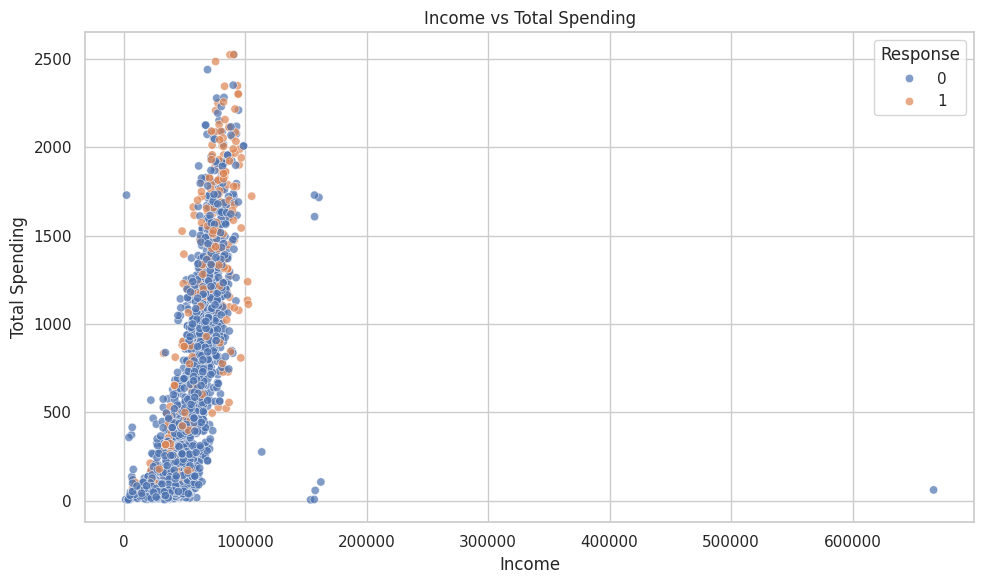

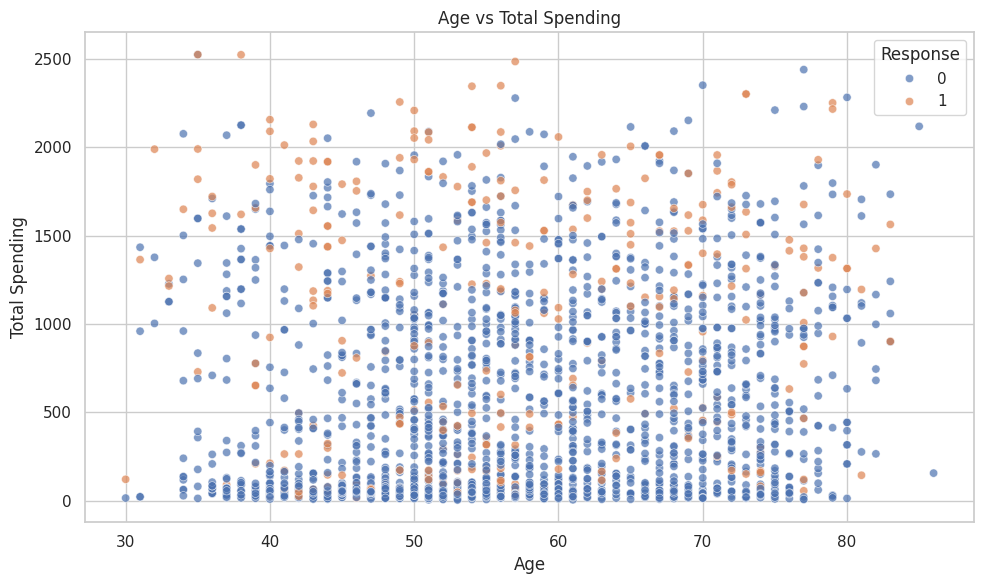

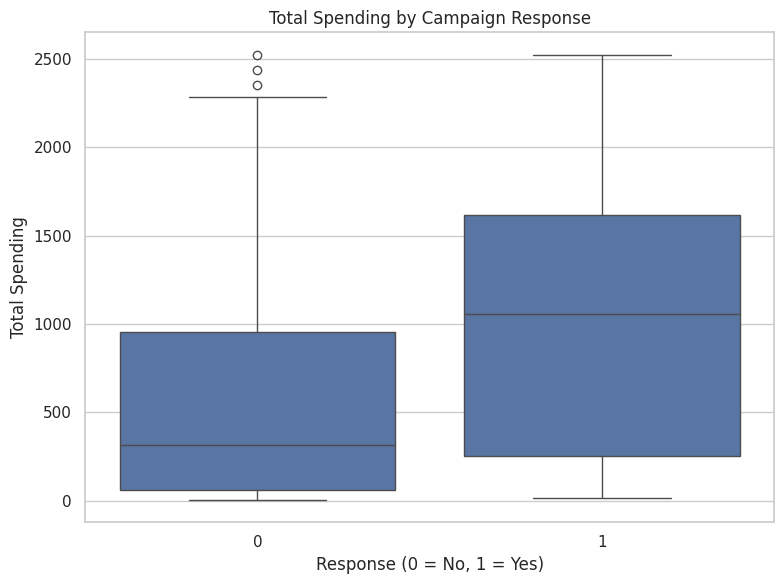

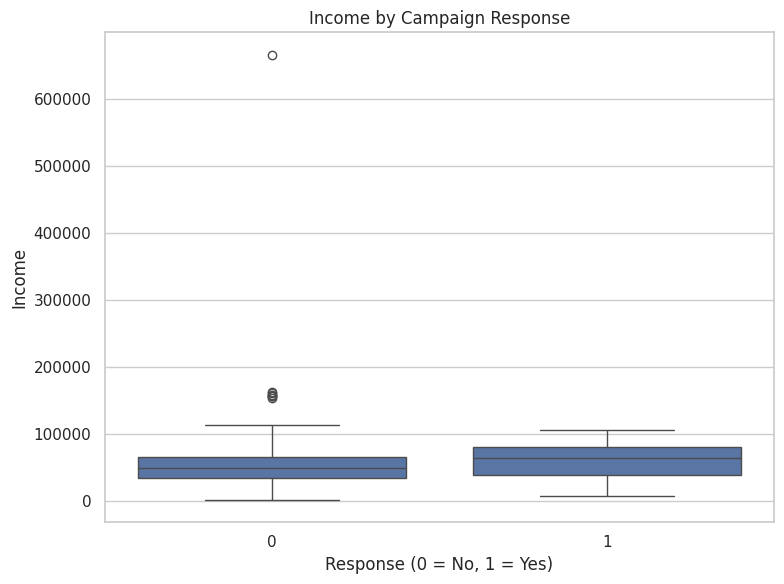

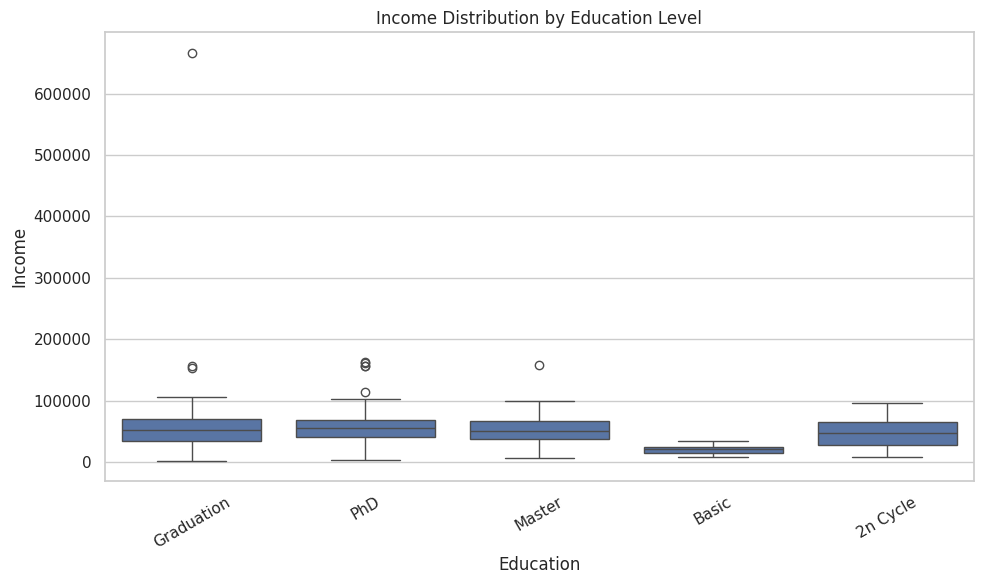

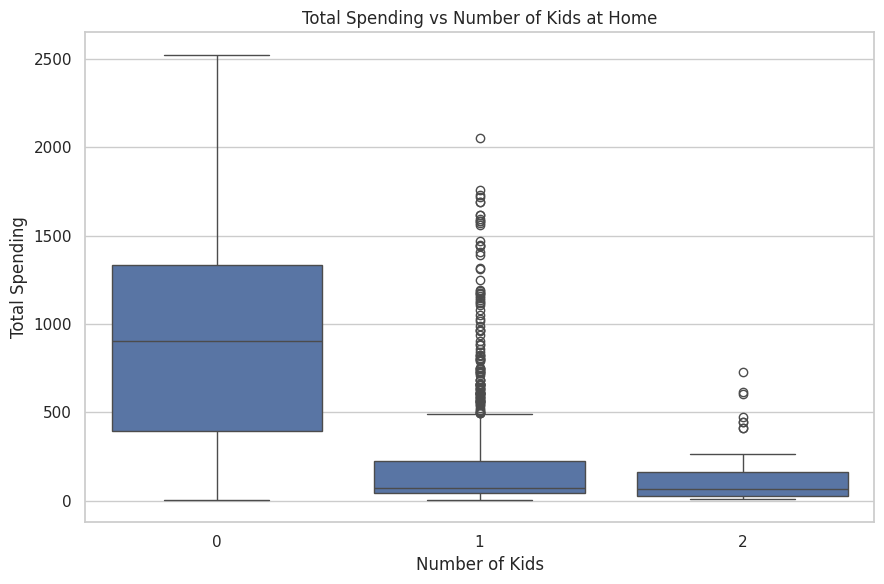

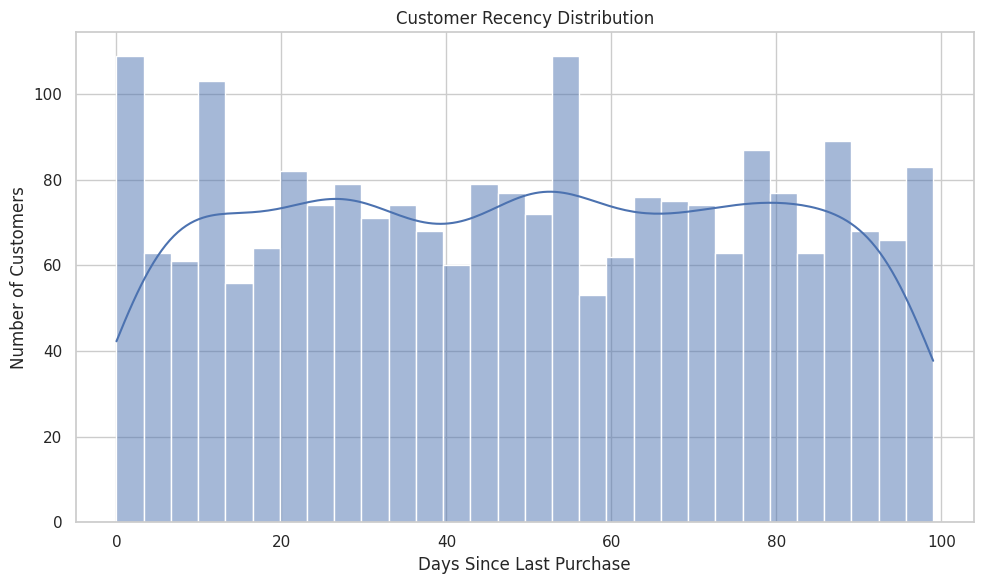

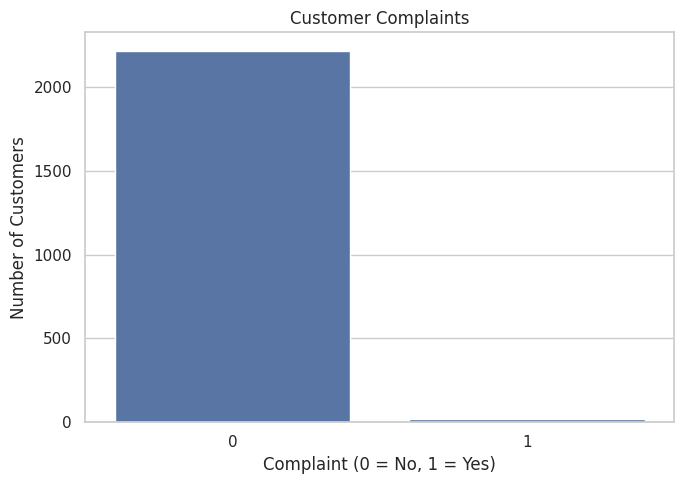

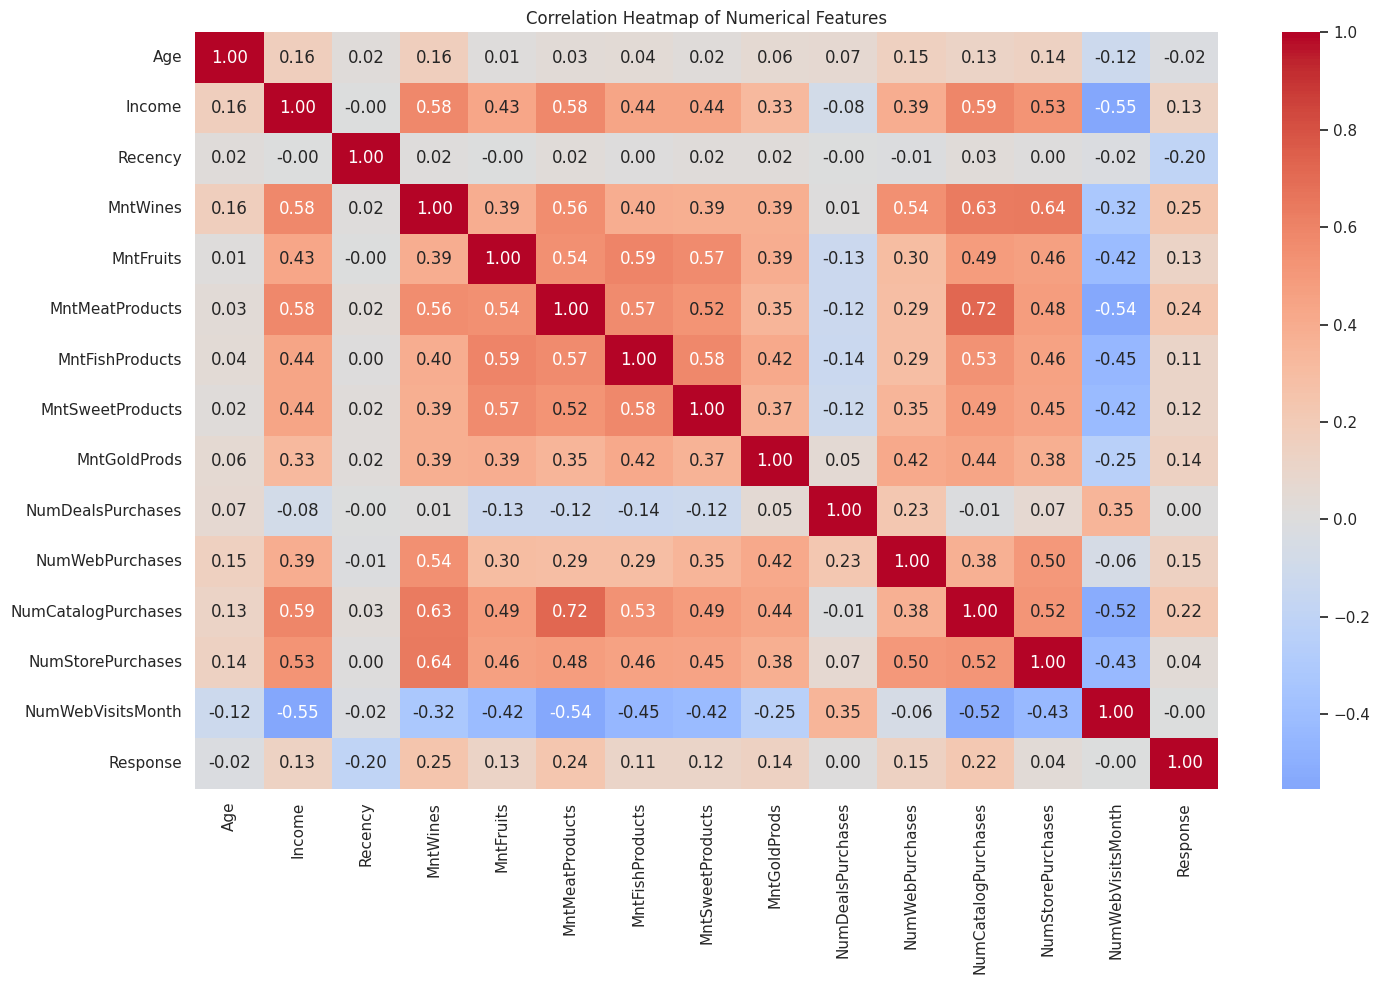

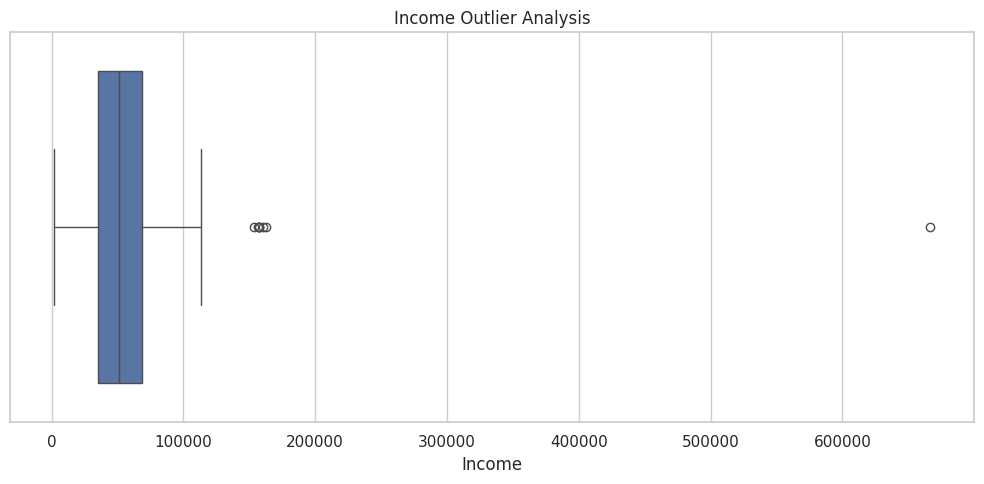

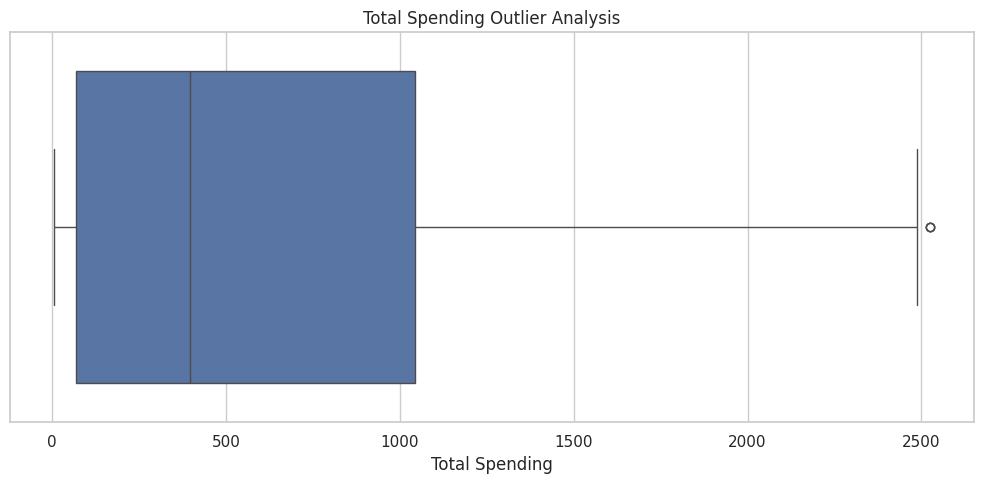

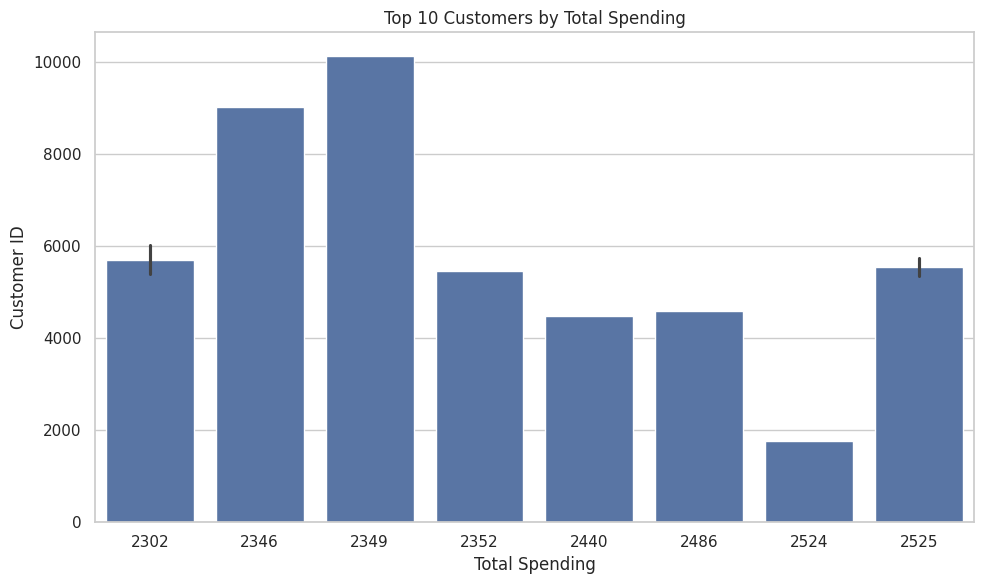



FINAL EDA SUMMARY
Number of Customers: 2237
Number of Features: 31
Average Age: 57.1
Average Income: 52236.58
Average Total Spending: 605.74
Campaign Response Rate: 14.93 %
Most Common Education: Graduation
Highest Spending Product Category: MntWines
Most Used Purchase Channel: NumStorePurchases
Total Complaints: 20


EDA REPORT COMPLETED SUCCESSFULLY


In [ ]:
# ============================================================
# CUSTOMER PERSONALITY ANALYSIS
# MARKETING CAMPAIGN DATASET - EDA REPORT
# ============================================================

# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set general plotting style
sns.set_theme(style="whitegrid")

# ============================================================
# 2. LOAD DATASET
# ============================================================

file_path = "/content/sample_data/marketing_campaign.csv"

# Dataset is TAB separated
df = pd.read_csv(file_path, sep="\t")

print("=" * 70)
print("CUSTOMER PERSONALITY ANALYSIS - EDA REPORT")
print("=" * 70)

print("\nDataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
print(df.head())


# ============================================================
# 3. DATASET INFORMATION
# ============================================================

print("\n" + "=" * 70)
print("DATASET INFORMATION")
print("=" * 70)

print("\nNumber of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nColumn Names:")
for column in df.columns:
    print("-", column)

print("\nData Types:")
print(df.dtypes)


# ============================================================
# 4. STATISTICAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("STATISTICAL SUMMARY")
print("=" * 70)

print(df.describe())


# ============================================================
# 5. MISSING VALUE ANALYSIS
# ============================================================

print("\n" + "=" * 70)
print("MISSING VALUE ANALYSIS")
print("=" * 70)

missing_values = df.isnull().sum()

print(missing_values)

print("\nTotal Missing Values:",
      df.isnull().sum().sum())


# Missing value visualization

plt.figure(figsize=(12, 6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Values Heatmap")
plt.xlabel("Features")
plt.ylabel("Customers")
plt.tight_layout()
plt.show()


# ============================================================
# 6. DUPLICATE ANALYSIS
# ============================================================

print("\n" + "=" * 70)
print("DUPLICATE ANALYSIS")
print("=" * 70)

print("Number of duplicate rows:",
      df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()

print("Shape after removing duplicates:",
      df.shape)


# ============================================================
# 7. DATA CLEANING
# ============================================================

# Convert income to numeric
df["Income"] = pd.to_numeric(
    df["Income"],
    errors="coerce"
)

# Convert date column
df["Dt_Customer"] = pd.to_datetime(
    df["Dt_Customer"],
    dayfirst=True,
    errors="coerce"
)

# Replace unusual marital status values
df["Marital_Status"] = df["Marital_Status"].replace(
    ["YOLO", "Absurd", "Alone"],
    "Other"
)

print("\nData cleaning completed.")


# ============================================================
# 8. CREATE AGE FEATURE
# ============================================================

current_year = 2026

df["Age"] = current_year - df["Year_Birth"]

# Remove unrealistic ages
df = df[
    (df["Age"] >= 18) &
    (df["Age"] <= 100)
].copy()

print("\nAge feature created successfully.")


# ============================================================
# 9. CREATE TOTAL SPENDING FEATURE
# ============================================================

spending_columns = [
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
]

df["Total_Spending"] = df[spending_columns].sum(axis=1)

print("Total_Spending feature created successfully.")


# ============================================================
# 10. AGE DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    df["Age"],
    bins=30,
    kde=True
)

plt.title("Distribution of Customer Age")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()


# ============================================================
# 11. INCOME DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    df["Income"].dropna(),
    bins=40,
    kde=True
)

plt.title("Distribution of Customer Income")
plt.xlabel("Income")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()


# ============================================================
# 12. EDUCATION DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

education_order = df["Education"].value_counts().index

sns.countplot(
    data=df,
    x="Education",
    order=education_order
)

plt.title("Customers by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Number of Customers")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()


# ============================================================
# 13. MARITAL STATUS DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

marital_order = df["Marital_Status"].value_counts().index

sns.countplot(
    data=df,
    x="Marital_Status",
    order=marital_order
)

plt.title("Customers by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Number of Customers")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()


# ============================================================
# 14. CHILDREN AND TEENAGERS AT HOME
# ============================================================

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Kidhome"
)

plt.title("Number of Kids at Home")
plt.xlabel("Number of Kids")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Teenhome"
)

plt.title("Number of Teenagers at Home")
plt.xlabel("Number of Teenagers")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()


# ============================================================
# 15. TOTAL SPENDING BY PRODUCT CATEGORY
# ============================================================

total_spending = (
    df[spending_columns]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=total_spending.values,
    y=total_spending.index
)

plt.title("Total Spending by Product Category")
plt.xlabel("Total Spending")
plt.ylabel("Product Category")

plt.tight_layout()
plt.show()


# ============================================================
# 16. AVERAGE SPENDING BY PRODUCT CATEGORY
# ============================================================

average_spending = (
    df[spending_columns]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=average_spending.values,
    y=average_spending.index
)

plt.title("Average Spending by Product Category")
plt.xlabel("Average Spending")
plt.ylabel("Product Category")

plt.tight_layout()
plt.show()


# ============================================================
# 17. PURCHASE CHANNEL ANALYSIS
# ============================================================

purchase_columns = [
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases"
]

purchase_totals = (
    df[purchase_columns]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 6))

sns.barplot(
    x=purchase_totals.index,
    y=purchase_totals.values
)

plt.title("Purchases by Shopping Channel")
plt.xlabel("Shopping Channel")
plt.ylabel("Total Purchases")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()


# ============================================================
# 18. DEAL PURCHASE ANALYSIS
# ============================================================

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="NumDealsPurchases"
)

plt.title("Purchases Made Using Deals")
plt.xlabel("Number of Deal Purchases")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()


# ============================================================
# 19. WEB VISITS ANALYSIS
# ============================================================

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="NumWebVisitsMonth"
)

plt.title("Number of Web Visits per Month")
plt.xlabel("Web Visits per Month")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()


# ============================================================
# 20. CAMPAIGN ACCEPTANCE ANALYSIS
# ============================================================

campaign_columns = [
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5"
]

campaign_totals = (
    df[campaign_columns]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=campaign_totals.index,
    y=campaign_totals.values
)

plt.title("Campaign Acceptance")
plt.xlabel("Campaign")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()


# ============================================================
# 21. LATEST CAMPAIGN RESPONSE
# ============================================================

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Response"
)

plt.title("Customer Response to Latest Campaign")
plt.xlabel("Response (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()


# ============================================================
# 22. RESPONSE RATE
# ============================================================

response_rate = (
    df["Response"].mean() * 100
)

print("\n" + "=" * 70)
print("CAMPAIGN RESPONSE RATE")
print("=" * 70)

print(
    f"Latest Campaign Response Rate: {response_rate:.2f}%"
)


# ============================================================
# 23. RESPONSE BY EDUCATION
# ============================================================

education_response = (
    pd.crosstab(
        df["Education"],
        df["Response"],
        normalize="index"
    ) * 100
)

education_response.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Campaign Response by Education Level")
plt.xlabel("Education")
plt.ylabel("Percentage (%)")

plt.xticks(rotation=30)

plt.legend(
    ["No Response", "Response"]
)

plt.tight_layout()
plt.show()


# ============================================================
# 24. RESPONSE BY MARITAL STATUS
# ============================================================

marital_response = (
    pd.crosstab(
        df["Marital_Status"],
        df["Response"],
        normalize="index"
    ) * 100
)

marital_response.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Campaign Response by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Percentage (%)")

plt.xticks(rotation=30)

plt.legend(
    ["No Response", "Response"]
)

plt.tight_layout()
plt.show()


# ============================================================
# 25. INCOME VS TOTAL SPENDING
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Income",
    y="Total_Spending",
    hue="Response",
    alpha=0.7
)

plt.title("Income vs Total Spending")
plt.xlabel("Income")
plt.ylabel("Total Spending")

plt.tight_layout()
plt.show()


# ============================================================
# 26. AGE VS TOTAL SPENDING
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Age",
    y="Total_Spending",
    hue="Response",
    alpha=0.7
)

plt.title("Age vs Total Spending")
plt.xlabel("Age")
plt.ylabel("Total Spending")

plt.tight_layout()
plt.show()


# ============================================================
# 27. TOTAL SPENDING BY RESPONSE
# ============================================================

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="Response",
    y="Total_Spending"
)

plt.title("Total Spending by Campaign Response")
plt.xlabel("Response (0 = No, 1 = Yes)")
plt.ylabel("Total Spending")

plt.tight_layout()
plt.show()


# ============================================================
# 28. INCOME BY RESPONSE
# ============================================================

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="Response",
    y="Income"
)

plt.title("Income by Campaign Response")
plt.xlabel("Response (0 = No, 1 = Yes)")
plt.ylabel("Income")

plt.tight_layout()
plt.show()


# ============================================================
# 29. EDUCATION VS INCOME
# ============================================================

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Education",
    y="Income"
)

plt.title("Income Distribution by Education Level")
plt.xlabel("Education")
plt.ylabel("Income")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()


# ============================================================
# 30. KIDS AT HOME VS TOTAL SPENDING
# ============================================================

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="Kidhome",
    y="Total_Spending"
)

plt.title("Total Spending vs Number of Kids at Home")
plt.xlabel("Number of Kids")
plt.ylabel("Total Spending")

plt.tight_layout()
plt.show()


# ============================================================
# 31. RECENCY DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Recency",
    bins=30,
    kde=True
)

plt.title("Customer Recency Distribution")
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()


# ============================================================
# 32. CUSTOMER COMPLAINT ANALYSIS
# ============================================================

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Complain"
)

plt.title("Customer Complaints")
plt.xlabel("Complaint (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()


# ============================================================
# 33. CORRELATION HEATMAP
# ============================================================

numeric_columns = [
    "Age",
    "Income",
    "Recency",
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds",
    "NumDealsPurchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth",
    "Response"
]

correlation = df[numeric_columns].corr()

plt.figure(figsize=(15, 10))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Numerical Features")

plt.tight_layout()
plt.show()


# ============================================================
# 34. OUTLIER ANALYSIS - INCOME
# ============================================================

plt.figure(figsize=(10, 5))

sns.boxplot(
    x=df["Income"]
)

plt.title("Income Outlier Analysis")
plt.xlabel("Income")

plt.tight_layout()
plt.show()


# ============================================================
# 35. OUTLIER ANALYSIS - TOTAL SPENDING
# ============================================================

plt.figure(figsize=(10, 5))

sns.boxplot(
    x=df["Total_Spending"]
)

plt.title("Total Spending Outlier Analysis")
plt.xlabel("Total Spending")

plt.tight_layout()
plt.show()


# ============================================================
# 36. TOP 10 CUSTOMERS BY SPENDING
# ============================================================

top_customers = df.nlargest(
    10,
    "Total_Spending"
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_customers,
    x="Total_Spending",
    y="ID"
)

plt.title("Top 10 Customers by Total Spending")
plt.xlabel("Total Spending")
plt.ylabel("Customer ID")

plt.tight_layout()
plt.show()


# ============================================================
# 37. FINAL EDA SUMMARY
# ============================================================

print("\n")
print("=" * 70)
print("FINAL EDA SUMMARY")
print("=" * 70)

print(
    "Number of Customers:",
    len(df)
)

print(
    "Number of Features:",
    len(df.columns)
)

print(
    "Average Age:",
    round(df["Age"].mean(), 2)
)

print(
    "Average Income:",
    round(df["Income"].mean(), 2)
)

print(
    "Average Total Spending:",
    round(df["Total_Spending"].mean(), 2)
)

print(
    "Campaign Response Rate:",
    round(df["Response"].mean() * 100, 2),
    "%"
)

print(
    "Most Common Education:",
    df["Education"].mode()[0]
)

print(
    "Highest Spending Product Category:",
    total_spending.index[0]
)

print(
    "Most Used Purchase Channel:",
    purchase_totals.index[0]
)

print(
    "Total Complaints:",
    df["Complain"].sum()
)

print("\n")
print("=" * 70)
print("EDA REPORT COMPLETED SUCCESSFULLY")
print("=" * 70)